In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df1 = pd.read_csv("FAOSTAT_data_1-10-2022.csv")
df2 = pd.read_csv("FAOSTAT_data_en_11-1-2024.csv")
countries = pd.read_csv("FAOSTAT_data_11-24-2020.csv")

In [3]:
df1.head()

df1.shape

df1.info()

df1.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229925 entries, 0 to 229924
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Domain Code       229925 non-null  object 
 1   Domain            229925 non-null  object 
 2   Area Code (FAO)   229925 non-null  int64  
 3   Area              229925 non-null  object 
 4   Element Code      229925 non-null  int64  
 5   Element           229925 non-null  object 
 6   Months Code       229925 non-null  int64  
 7   Months            229925 non-null  object 
 8   Year Code         229925 non-null  int64  
 9   Year              229925 non-null  int64  
 10  Unit              229925 non-null  object 
 11  Value             222012 non-null  float64
 12  Flag              229925 non-null  object 
 13  Flag Description  229925 non-null  object 
dtypes: float64(1), int64(5), object(8)
memory usage: 24.6+ MB


,Area Code (FAO),Element Code,Months Code,Year Code,Year,Value
count,229925.000000,229925.0,229925.000000,229925.000000,229925.000000,222012.000000
mean,130.647689,7271.0,7009.882353,1991.306248,1991.306248,0.492626
std,76.809008,0.0,6.037955,17.333252,17.333252,1.036364
min,1.000000,7271.0,7001.000000,1961.000000,1961.000000,-9.303000
25%,64.000000,7271.0,7005.000000,1976.000000,1976.000000,-0.071000
50%,131.000000,7271.0,7009.000000,1992.000000,1992.000000,0.414000
75%,194.000000,7271.0,7016.000000,2006.000000,2006.000000,0.999000
max,351.000000,7271.0,7020.000000,2020.000000,2020.000000,11.759000


In [9]:
import pandas as pd

df = pd.DataFrame({
    'Area': ['A1', 'A2', 'A3'],
    'Months': ['Jan', 'Feb', 'Mar'],
    'Year': [2021, 2022, 2023],
    'Value': [100, 200, 300],
    'ExtraColumn': [1, 2, 3]
})

df_clean = df[['Area', 'Months', 'Year', 'Value']]

In [10]:
df_clean.columns = ['Country','Month','Year','TemperatureChange']

In [15]:
df_clean['Year'] = df_clean['Year'].astype(int)
df_clean['TemperatureChange'] = pd.to_numeric(df_clean['TemperatureChange'], errors='coerce')

In [16]:
df_clean.isnull().sum()

Country              0
Month                0
Year                 0
TemperatureChange    0
dtype: int64

In [17]:
df_clean = df_clean.dropna()

In [26]:
df_clean.duplicated().sum()

np.int64(0)

In [19]:
df_clean = df_clean.drop_duplicates()

In [20]:
df_clean.describe()

,Year,TemperatureChange
count,3.0,3.0
mean,2022.0,200.0
std,1.0,100.0
min,2021.0,100.0
25%,2021.5,150.0
50%,2022.0,200.0
75%,2022.5,250.0
max,2023.0,300.0


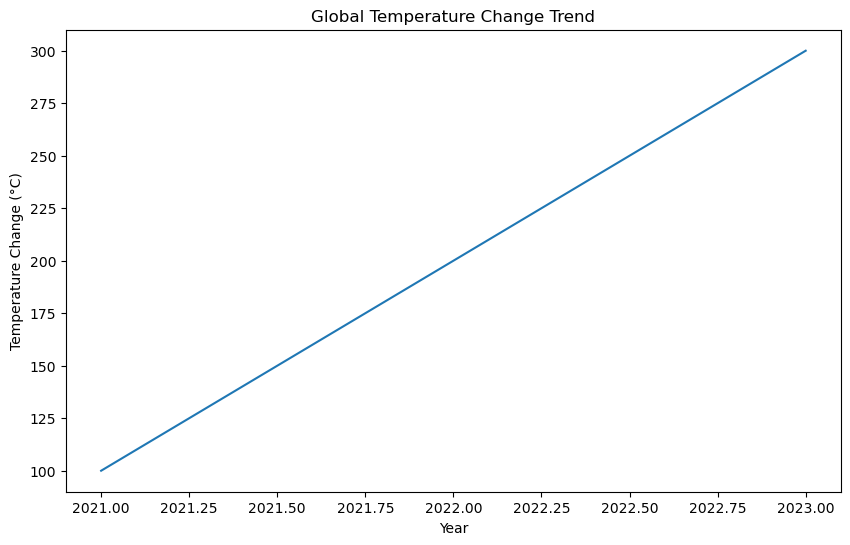

In [27]:
yearly_temp = df_clean.groupby("Year")["TemperatureChange"].mean()

plt.figure(figsize=(10,6))
plt.plot(yearly_temp)
plt.title("Global Temperature Change Trend")
plt.xlabel("Year")
plt.ylabel("Temperature Change (°C)")
plt.show()

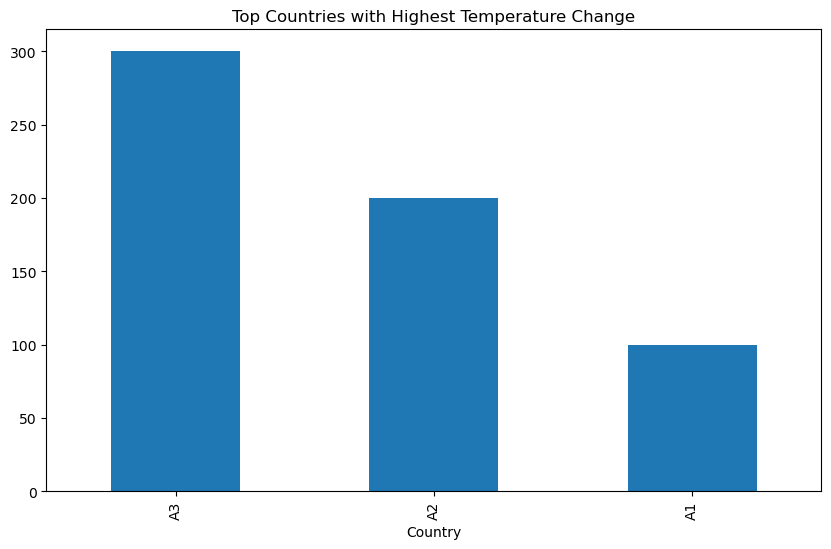

In [22]:
country_temp = df_clean.groupby("Country")["TemperatureChange"].mean()

top_countries = country_temp.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_countries.plot(kind="bar")
plt.title("Top Countries with Highest Temperature Change")
plt.show()

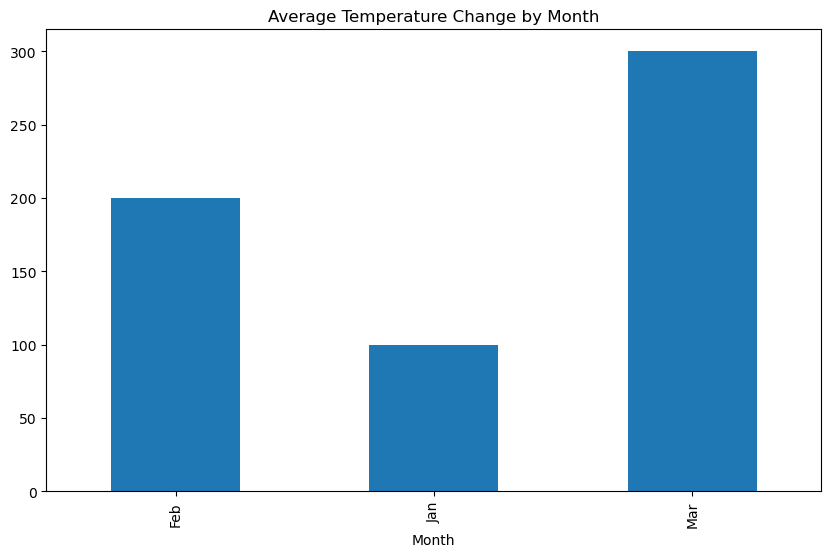

In [23]:
monthly_temp = df_clean.groupby("Month")["TemperatureChange"].mean()

plt.figure(figsize=(10,6))
monthly_temp.plot(kind="bar")
plt.title("Average Temperature Change by Month")
plt.show()

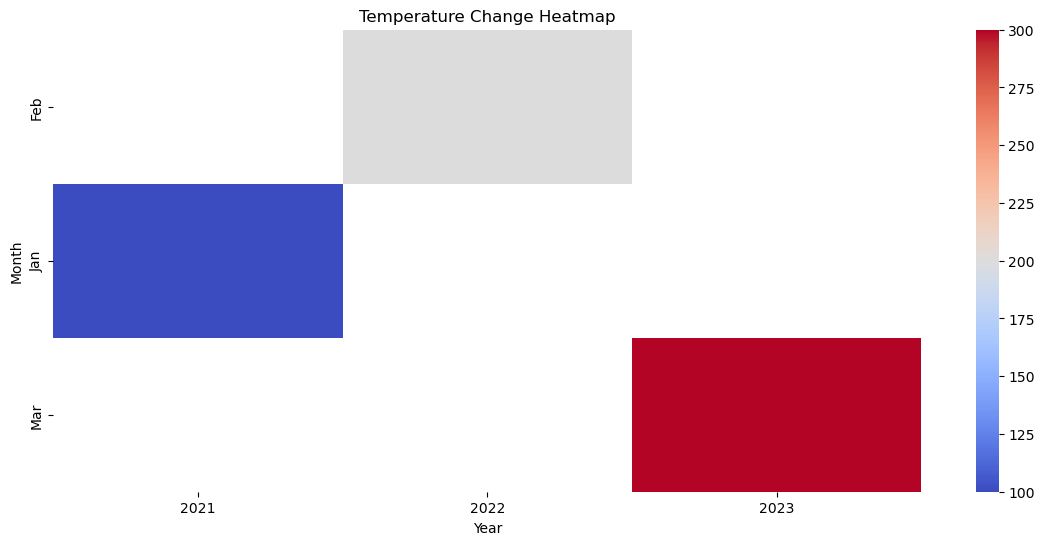

In [24]:
pivot_table = df_clean.pivot_table(
    values='TemperatureChange',
    index='Month',
    columns='Year',
    aggfunc='mean'
)

plt.figure(figsize=(14,6))
sns.heatmap(pivot_table, cmap='coolwarm')
plt.title("Temperature Change Heatmap")
plt.show()

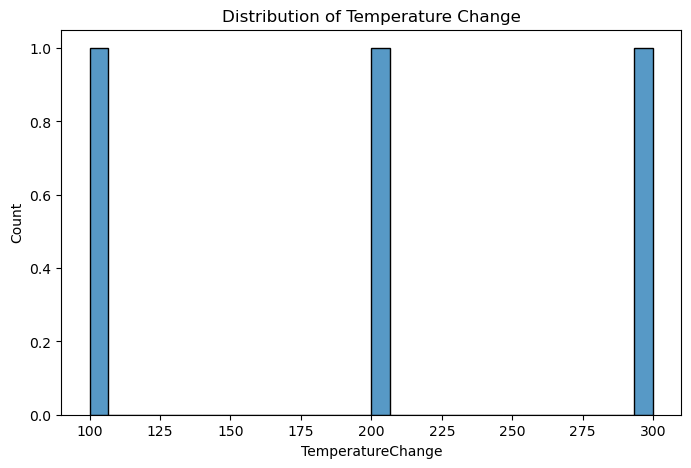

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean['TemperatureChange'], bins=30)
plt.title("Distribution of Temperature Change")
plt.show()